In [3]:
!pip install tensorflow matplotlib numpy

In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Version: 2.21.0
GPU Available: False


In [8]:

import tensorflow as tf

# Define constants
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

# Set the path to your dataset folder (update this path to your folder location)
dataset_path = r"C:\\Users\\Asus\\Desktop\\IIT INTERNSHIP\\AIIMAGE PROJECT\\dataset" 

# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Get class names
class_names = train_ds.class_names
print("Classes found:", class_names)

# Data Augmentation layer to make the model more robust
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

# Normalize pixel values to [0, 1] range
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
Classes found: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [9]:
from tensorflow.keras import layers, models

# Get the number of classes dynamically
num_classes = len(class_names)

# Build the CNN model
model = models.Sequential([
    # Data augmentation block built right into the model
    data_augmentation,
    
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(),
    
    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    # Dropout for regularization to prevent overfitting
    layers.Dropout(0.2),
    
    # Flatten features to feed into dense layers
    layers.Flatten(),
    
    # Dense Hidden Layer
    layers.Dense(128, activation='relu'),
    
    # Output Layer with softmax activation for multi-class classification
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Print model architecture summary
model.build((None, 150, 150, 3))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402,437 (20.61 MB)

 Trainable params: 5,402,437 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Number of epochs for training
EPOCHS = 10

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


108/108 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.4658 - loss: 1.2661 - val_accuracy: 0.5574 - val_loss: 1.0739
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.5866 - loss: 1.0501 - val_accuracy: 0.6477 - val_loss: 0.8973
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.6138 - loss: 0.9667 - val_accuracy: 0.6350 - val_loss: 0.9310
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.6465 - loss: 0.8979 - val_accuracy: 0.6802 - val_loss: 0.7807
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.6783 - loss: 0.8576 - val_accuracy: 0.6906 - val_loss: 0.7882
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.6836 - loss: 0.8235 - val_accuracy: 0.6906 - val_loss: 0.7947
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.6989 - loss: 0.7866 - val_accuracy: 0.6906 - val_loss: 0.7672
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.7148 - loss: 0.7604 - val_accuracy: 0.708

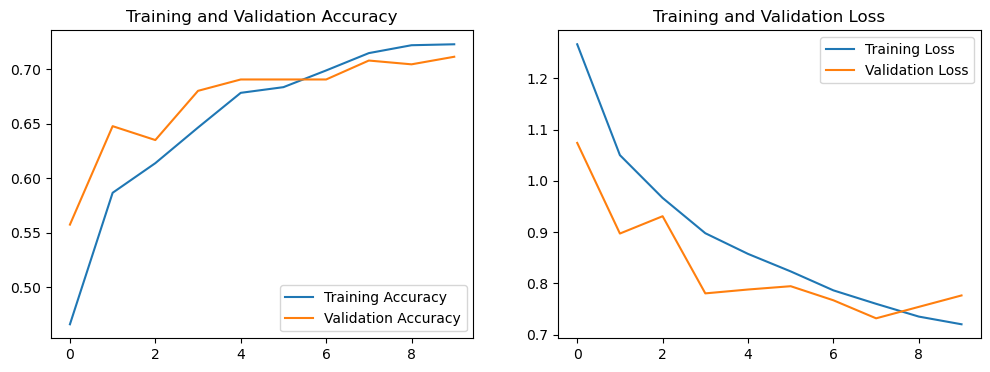

In [11]:
# Extract accuracy and loss values from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

# Plot Training and Validation Accuracy & Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step


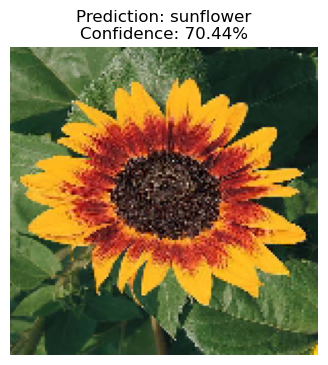

✅ This image most likely belongs to: **sunflower** with a confidence of 70.44%


In [12]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Path to a test image you want to recognize

img_path = r"C:\Users\Asus\Desktop\IIT INTERNSHIP\AIIMAGE PROJECT\test_image.jpeg"

# Load and resize the image to the target size (150x150)
img = load_img(img_path, target_size=(150, 150))
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch (1, 150, 150, 3)

# Normalize the image pixels (just like we did during training)
img_array = img_array / 255.0

# Predict the class
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions[0])]
confidence = 100 * np.max(predictions[0])

# Display the image and the result
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print(f"✅ This image most likely belongs to: **{predicted_class}** with a confidence of {confidence:.2f}%")

Generating predictions on validation set...
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step

--- Classification Report ---
              precision    recall  f1-score   support

       daisy       0.70      0.80      0.75       143
   dandelion       0.79      0.74      0.76       200
        rose       0.61      0.60      0.61       159
   sunflower       0.68      0.89      0.77       148
       tulip       0.77      0.59      0.67       213

    accuracy                           0.71       863
   macro avg       0.71      0.72      0.71       863
weighted avg       0.72      0.71      0.71       863



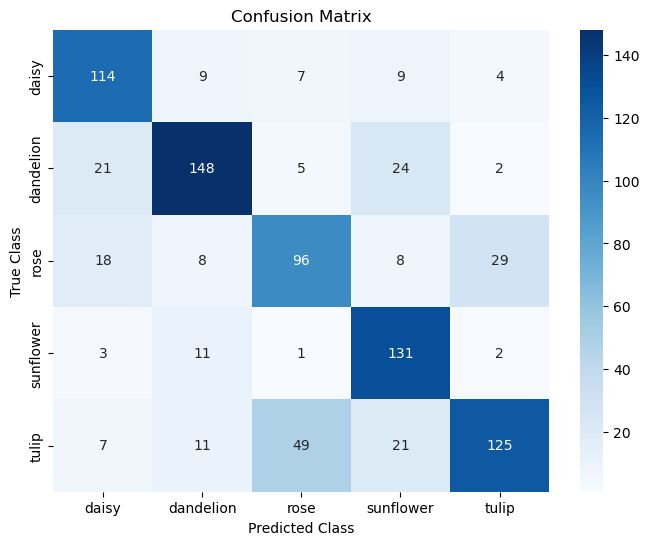

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as seaborn_plt
import numpy as np

# Collect all validation images and true labels
val_images_list = []
val_labels_list = []

for images, labels in val_ds:
    val_images_list.append(images)
    val_labels_list.append(labels)

val_images = np.concatenate(val_images_list)
val_labels = np.concatenate(val_labels_list)

# Generate predictions for the entire validation set
print("Generating predictions on validation set...")
predictions = model.predict(val_images)
y_pred = np.argmax(predictions, axis=1)

# Print detailed Classification Report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(val_labels, y_pred, target_names=class_names))

# Plot Confusion Matrix using Seaborn
cm = confusion_matrix(val_labels, y_pred)
plt.figure(figsize=(8, 6))
seaborn_plt.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()

In [14]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

# 1. Load the pre-trained MobileNetV2 base (excluding top classification layers)
base_model = MobileNetV2(input_shape=(150, 150, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model layers so we keep their learned feature extraction
base_model.trainable = False

# 2. Add custom classification head on top
inputs = tf.keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs) # keep data augmentation
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

high_acc_model = Model(inputs, outputs)

# 3. Compile with a slightly lower learning rate for stable fine-tuning
high_acc_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# 4. Train for 10 epochs (Watch how fast and high accuracy climbs!)
history_high = high_acc_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

C:\Users\Asus\AppData\Local\Temp\ipykernel_15200\1995087162.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3),


Epoch 1/10


c:\btech_proj\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


108/108 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.2901 - loss: 1.8961 - val_accuracy: 0.3940 - val_loss: 1.4477
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 106s 978ms/step - accuracy: 0.4331 - loss: 1.4402 - val_accuracy: 0.5446 - val_loss: 1.1471
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 141s 968ms/step - accuracy: 0.5394 - loss: 1.1998 - val_accuracy: 0.6234 - val_loss: 0.9778
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.5819 - loss: 1.0930 - val_accuracy: 0.6582 - val_loss: 0.8779
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 101s 930ms/step - accuracy: 0.6338 - loss: 0.9779 - val_accuracy: 0.6952 - val_loss: 0.8132
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 137s 890ms/step - accuracy: 0.6676 - loss: 0.9037 - val_accuracy: 0.7103 - val_loss: 0.7692
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 100s 929ms/step - accuracy: 0.6694 - loss: 0.8807 - val_accuracy: 0.7254 - val_loss: 0.7284
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 96s 890ms/step - accuracy: 0.6960 - loss: 0.8343 - va

In [15]:
# 1. Unfreeze the base model for fine-tuning
base_model.trainable = True

# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 2. Recompile with an even smaller learning rate for delicate fine-tuning
high_acc_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very low learning rate
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# 3. Train for 5 more epochs
FINE_TUNE_EPOCHS = 5
total_epochs = 10 + FINE_TUNE_EPOCHS

history_fine = high_acc_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history.epoch[-1],
    epochs=total_epochs
)

Epoch 10/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.6636 - loss: 0.9038 - val_accuracy: 0.7671 - val_loss: 0.6153
Epoch 11/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7270 - loss: 0.7444 - val_accuracy: 0.7868 - val_loss: 0.5767
Epoch 12/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7452 - loss: 0.6724 - val_accuracy: 0.8030 - val_loss: 0.5486
Epoch 13/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.7652 - loss: 0.6237 - val_accuracy: 0.8065 - val_loss: 0.5266
Epoch 14/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7808 - loss: 0.5922 - val_accuracy: 0.8169 - val_loss: 0.5123
Epoch 15/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.7840 - loss: 0.5639 - val_accuracy: 0.8227 - val_loss: 0.4924


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


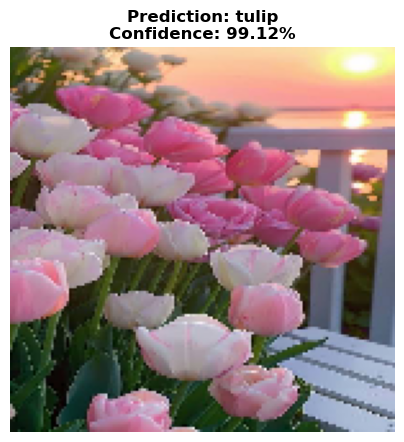

✅ Predicted Class: **tulip**
📊 Confidence Score: **99.12%**


In [16]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# 📂 Provide the exact path to your test image here
img_path = r"C:\Users\Asus\Desktop\IIT INTERNSHIP\AIIMAGE PROJECT\images.jpeg" 

# Load and resize the image to the target size (150x150)
img = load_img(img_path, target_size=(150, 150))
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch dimension (1, 150, 150, 3)

# Normalize the image pixels to [0, 1]
img_array = img_array / 255.0

# Predict using your fine-tuned high-accuracy model (high_acc_model)
predictions = high_acc_model.predict(img_array)
predicted_class = class_names[np.argmax(predictions[0])]
confidence = 100 * np.max(predictions[0])

# Display the image with the prediction result title
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%", fontsize=12, fontweight='bold')
plt.show()

print(f"✅ Predicted Class: **{predicted_class}**")
print(f"📊 Confidence Score: **{confidence:.2f}%**")

In [22]:
import os
import shutil

# This will remove the default Keras cache folder where corrupted weights live
keras_cache_dir = os.path.expanduser('~/.keras/models')
if os.path.exists(keras_cache_dir):
    shutil.rmtree(keras_cache_dir)
    print("🧹 Successfully cleared corrupted Keras model cache!")
else:
    print("Cache directory not found at default path, let's try downloading with a fresh filename.")

🧹 Successfully cleared corrupted Keras model cache!


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 24s 2us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step


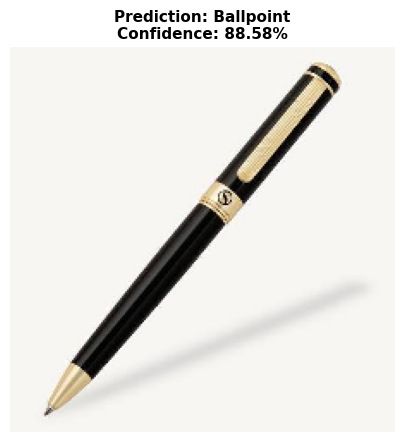

🔍 Top 3 Classifications for this image:
1. Ballpoint — 88.58% confidence
2. Fountain Pen — 6.60% confidence
3. Rubber Eraser — 0.29% confidence


In [23]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# 1. Load MobileNetV2 pre-trained on ImageNet (contains 1,000 general classes)
general_model = MobileNetV2(weights='imagenet')

# 2. Path to your test image
img_path = r"C:\Users\Asus\Desktop\IIT INTERNSHIP\AIIMAGE PROJECT\pen.jpeg"

# 3. Load and resize image to 224x224 (native input size for ImageNet models)
img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x) # Specialized scaling for ImageNet models

# 4. Make prediction
preds = general_model.predict(x)

# 5. Decode predictions to get human-readable names and confidence scores (Top 3)
decoded_preds = decode_predictions(preds, top=3)[0]

# Display the image with the top prediction title
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
top_label = decoded_preds[0][1].replace('_', ' ').title()
top_conf = decoded_preds[0][2] * 100
plt.title(f"Prediction: {top_label}\nConfidence: {top_conf:.2f}%", fontsize=11, fontweight='bold')
plt.show()

# Print the top 3 guesses in the console
print("🔍 Top 3 Classifications for this image:")
for i, (imagenet_id, label, score) in enumerate(decoded_preds):
    formatted_label = label.replace('_', ' ').title()
    print(f"{i+1}. {formatted_label} — {score*100:.2f}% confidence")